# HW1
## TODO:  Your ID goes here:

#### TODO: You emails for here:

## Introduction
This is the first Deep Learning assignment of the course.
It is divided into three sections:
1. Toy classification tasks (50 pts.)
2. Toy regressions tasks (30 pts.)
3. MNIST (binary) classification task (20 pts.)

See the instructions before each section.
You are not required to normalize the data in sections 1 and 2.

## Submission
The deadline for the task is 12.12.2024 end of day.
You may work in teams of 2 or 3.

Submission is via Moodle. Submit the **already run** notebook (i.e., with its output, figures, etc.,).

#Section 1: Classification Tasks
## TODO
For the entire section, do the following (i.e., only once):
1. Write a training function that returns the trained model and training loss
2. Write a plotting function to plot the training loss
3. Write a plotting function that scatter plots the predicted labels and decision boundaries.
4. Write a preprocessing function to handle the data (convert to pytorch tensor, etc).
5. Write an evaluation function that prints the set accuracy (train/test)

For each of the 5 exercises, do the following:
1. Create either a linear classifier if the problem seems linearly separable or an MLP using PyTorch. Explain your choice.
2. Train the model and plot the loss across epochs.
3. Plot the predicted labels and decision boundaries for the train set. Show the accuracy in the title (up to 3 decimals points).
4. Plot the predicted labels and decision boundaries for the test set.  Show the accuracy in the title (up to 3 decimals points).
5. Do NOT change the random seed of the data generation functions.
6. Create a Markdown cell and explain briefly (2-3 lines): why did the model perform well/poorly? What affected your design choices? What did you learn from previous attempts?


EX5 has further instructions.

## Grading:
**Accuracy** computed on the test set:
1. 80-100%: 10 pts (full grade)
2. 70-80%: 8pts
3. 60-70%: 6pts
4. < 60%: 5pts

You will also be graded on the correctness of your code and the discussion that follows each excersice.



## Setup
## DO NOT MODIFY THESE FUNCTIONS

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D


In [4]:

### EX1
def random_points_in_triangle(v1, v2, v3, n_points):
    points = []
    for _ in range(n_points):
        r1, r2 = np.random.rand(2)
        sqrt_r1 = np.sqrt(r1)
        point = (1 - sqrt_r1) * v1 + sqrt_r1 * (1 - r2) * v2 + sqrt_r1 * r2 * v3
        points.append(point)
    return np.array(points)

def generate_symmetric_triangles_data(K=3, N=100, random_state=42):
    np.random.seed(random_state)
    # Define vertices for three symmetric triangles
    side_length = 2
    height = np.sqrt(3) * side_length / 2
    triangles = [
        (np.array([0, 0]), np.array([side_length, 0]), np.array([side_length / 2, height])),
        (np.array([0, 0]), np.array([-side_length, 0]), np.array([-side_length / 2, height])),
        (np.array([0, 0]), np.array([1.5, -height]), np.array([-1.5, -height]))
    ]

    X, y = [], []
    for i, (v1, v2, v3) in enumerate(triangles):
        points = random_points_in_triangle(v1, v2, v3, N)
        X.append(points)
        y += [i] * N

    X = np.vstack(X)
    y = np.array(y)
    return X, y

### EX2
def generate_grid_data(grid_size=4, min_points=5, max_points=20, random_state=42):
    np.random.seed(random_state)
    X, y = [], []
    half_grid_size = grid_size // 2

    for i in range(grid_size):
        for j in range(grid_size):
            n_points = np.random.randint(min_points, max_points + 1)
            x_offset = i - half_grid_size + 0.5
            y_offset = j - half_grid_size + 0.5
            # Generate points more centered within the square
            points = 0.8 * (np.random.rand(n_points, 2) - 0.5) + [x_offset, y_offset]
            X.append(points)
            label = (i + j) % 2
            y += [label] * n_points

    X = np.vstack(X)
    y = np.array(y)
    return X, y

### EX3
def generate_concentric_circles_data(radii=[1, 2, 3, 4], points_per_circle=100, random_state=42):
    np.random.seed(random_state)
    X, y = [], []

    for i, radius in enumerate(radii):
        angles = np.linspace(0, 2 * np.pi, points_per_circle, endpoint=False)
        circle_x = radius * np.cos(angles) + np.random.normal(0, 0.1, points_per_circle)
        circle_y = radius * np.sin(angles) + np.random.normal(0, 0.1, points_per_circle)
        X.append(np.vstack((circle_x, circle_y)).T)
        y += [i] * points_per_circle

    X = np.vstack(X)
    y = np.array(y)
    return X, y

### EX4
def generate_nested_rectangles_data(inner_rect=(2, 1), middle_rect=(4, 2), outer_rect=(6, 3), points_per_rectangle=100, random_state=42):
    np.random.seed(random_state)
    X, y = [], []

    # Inner rectangle
    width, height = inner_rect
    x_points = width * (np.random.rand(points_per_rectangle) - 0.5)
    y_points = height * (np.random.rand(points_per_rectangle) - 0.5)
    X.append(np.vstack((x_points, y_points)).T)
    y += [0] * points_per_rectangle

    # Middle rectangle
    width, height = middle_rect
    x_points = width * (np.random.rand(points_per_rectangle) - 0.5)
    y_points = height * (np.random.rand(points_per_rectangle) - 0.5)
    # Exclude points that fall inside the inner rectangle
    mask = (np.abs(x_points) > inner_rect[0] / 2) | (np.abs(y_points) > inner_rect[1] / 2)
    X.append(np.vstack((x_points[mask], y_points[mask])).T)
    y += [1] * len(x_points[mask])

    # Outer rectangle
    width, height = outer_rect
    x_points = width * (np.random.rand(points_per_rectangle) - 0.5)
    y_points = height * (np.random.rand(points_per_rectangle) - 0.5)
    # Exclude points that fall inside the middle rectangle
    mask = (np.abs(x_points) > middle_rect[0] / 2) | (np.abs(y_points) > middle_rect[1] / 2)
    X.append(np.vstack((x_points[mask], y_points[mask])).T)
    y += [2] * len(x_points[mask])

    X = np.vstack(X)
    y = np.array(y)
    return X, y


def plot_data(X, y, title=""):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend(handles=scatter.legend_elements()[0], labels=set(y), title="Classes")
    plt.show()



# TODO - your general functions for Section 1

---



In [5]:
### Your code goes here (you may break this part to more than one cell) ####
### Imports
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### Preprocessing function ####
def preprocess(X_train, y_train, X_test=None, y_test=None, batch_size=32):
    # 1. Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)

    # 2. Train dataset + loader
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # 3. Optional test loader
    test_loader = None
    if X_test is not None and y_test is not None:
        x_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor  = torch.tensor(y_test, dtype=torch.long)
        test_dataset = torch.utils.data.TensorDataset(x_test_tensor, y_test_tensor)
        test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 4. Useful info for building the model
    input_dim   = X_train.shape[1]
    num_classes = len(torch.unique(y_train))

    return train_loader, test_loader, input_dim, num_classes




### Training function ###
def train_model(model, train_loader, criterion, optimizer, num_epochs=100, device=None):
    """
    Training loop for a PyTorch model.
    Returns:
        - trained model
        - list of training losses (one value per epoch)
    """

    # If no device is given, choose GPU if available, otherwise CPU
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the model to the selected device (CPU or GPU)
    model.to(device)

    # List for saving the loss of each epoch
    train_losses = []

    # Loop over all epochs (full passes over the dataset)
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode (important for layers like Dropout)

        running_loss = 0.0   # Total loss for this epoch
        num_samples = 0      # How many samples we processed

        # Loop over all batches in the training dataset
        for X_batch, y_batch in train_loader:

            # Move the batch data to the device (CPU/GPU)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Clear old gradients from previous step
            optimizer.zero_grad()

            # Forward pass: compute model predictions
            outputs = model(X_batch)

            # Compute how wrong the predictions are
            loss = criterion(outputs, y_batch)

            # Backward pass: compute gradients of loss w.r.t parameters
            loss.backward()

            # Update the model parameters using the optimizer
            optimizer.step()

            # Get batch size (how many samples are inside this batch)
            batch_size = X_batch.size(0)

            # Add the batch loss to the running total (multiply by batch size)
            running_loss += loss.item() * batch_size

            # Count how many samples we processed so far
            num_samples += batch_size

        # Compute average loss over all samples in this epoch
        epoch_loss = running_loss / num_samples

        # Save this epoch's loss
        train_losses.append(epoch_loss)

        # Optional: print progress
        # print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

    # Return trained model and list of epoch losses
    return model, train_losses


### Plot training loss function ###


def plot_training_loss(train_losses):
    """
    Plot the training loss per epoch.

    Args:
        train_losses: list of floats.
                      train_losses[i] is the loss at epoch (i+1).
    """
    # Create a list of epoch numbers: [1, 2, 3, ..., num_epochs]
    epochs = range(1, len(train_losses) + 1)
    # Start a new figure (a new empty plot)
    plt.figure()
    # Draw the loss curve: x = epochs, y = loss values
    plt.plot(epochs, train_losses, marker="o")
    # Add a label for the x-axis
    plt.xlabel("Epoch")
    # Add a label for the y-axis
    plt.ylabel("Training Loss")
    # Add a title at the top of the plot
    plt.title("Training Loss per Epoch")
    # (Optional) Add a grid to make it easier to read values
    plt.grid(True)
    # Show the plot on the screen
    plt.show()


### Plot predicted labels and decision boundaries ###
def evaluate_accuracy(model, data_loader, device=None):
    """
    Calculates accuracy on a given dataset (train or test).
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)

    # 1. Set model to evaluation mode
    model.eval()

    correct = 0
    total = 0

    # 2. Turn off gradient calculation
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # 3. Forward pass
            outputs = model(X_batch)

            # 4. Get predictions (class with highest score)
            # torch.max returns (values, indices). We only need indices (the class ID).
            _, predicted = torch.max(outputs, 1)

            # 5. Count correct predictions
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = correct / total
    print(f"Accuracy: {accuracy:.3f}")
    return accuracy

### Evaluation function ###

def plot_decision_boundary(model, X, y, device=None, title="Decision Boundary"):
    """
    Plots the data points and the decision boundary of the model.
    X, y: Original numpy arrays (not tensors/loaders) for easy plotting.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # 1. Create a meshgrid (the background grid)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 2. Flatten and convert to tensor for the model
    # ravel() flattens the array. np.c_ stacks them side-by-side to make (N, 2) coordinates
    mesh_input = np.c_[xx.ravel(), yy.ravel()]
    mesh_tensor = torch.tensor(mesh_input, dtype=torch.float32).to(device)

    # 3. Get predictions for the whole grid
    with torch.no_grad():
        outputs = model(mesh_tensor)
        _, preds = torch.max(outputs, 1)

    # 4. Reshape predictions to match the grid shape
    Z = preds.cpu().numpy().reshape(xx.shape)

    # 5. Plotting
    plt.figure(figsize=(8, 6))

    # Draw the filled contour (the background colors)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # scatter plot of the actual data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(handles=scatter.legend_elements()[0], labels=set(y), title="Classes")
    plt.show()

## EX1

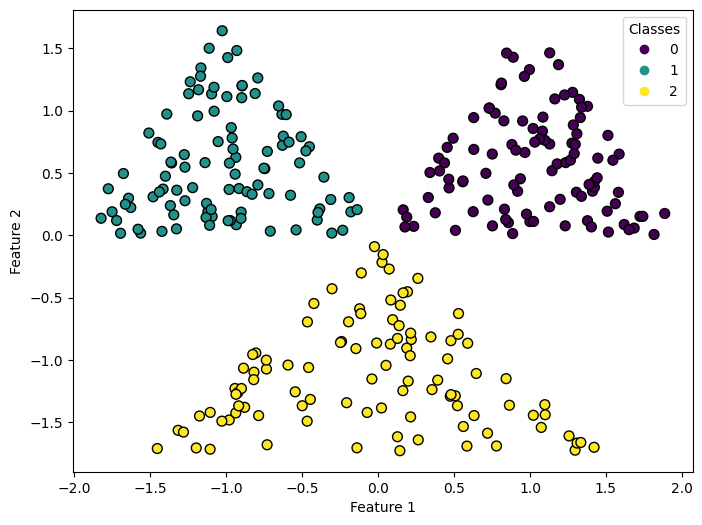

In [6]:
# Generate the data
X_train, y_train = generate_symmetric_triangles_data(random_state=0)
X_test, y_test = generate_symmetric_triangles_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)

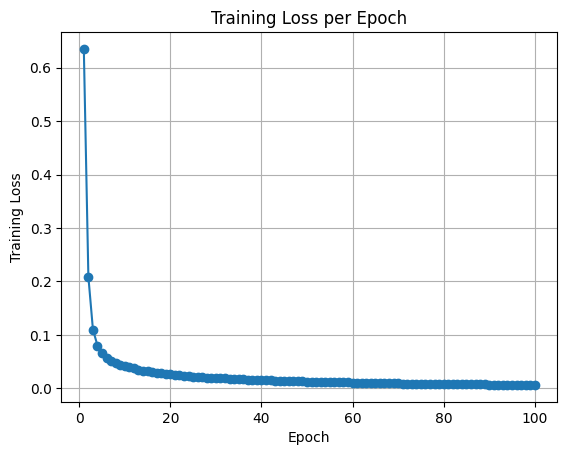

Evaluating Train Set:
Accuracy: 1.000


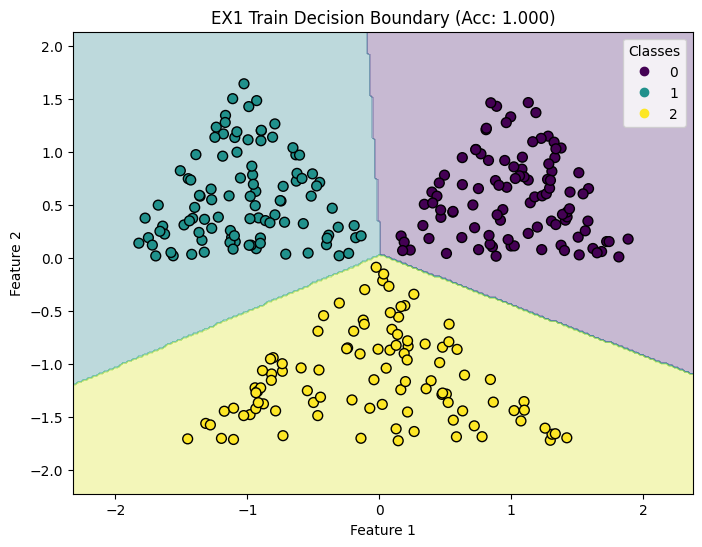


Evaluating Test Set:
Accuracy: 0.997


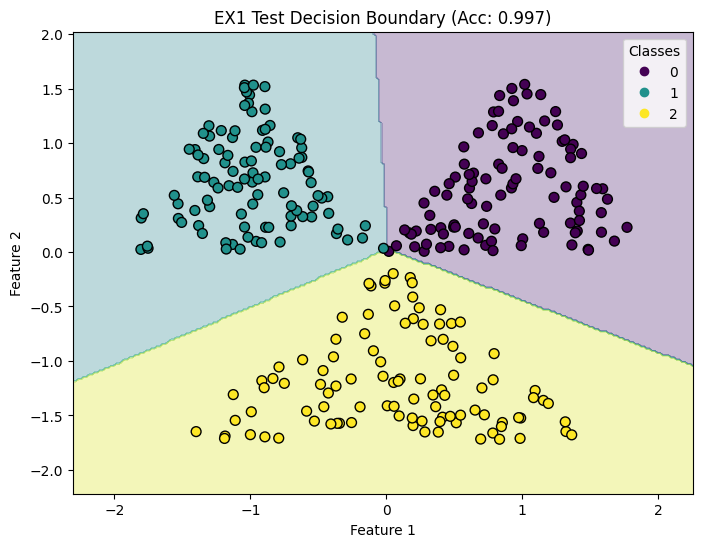

In [7]:
### Your code goes here ####

### 2. Preprocessing
# Use the helper function we defined earlier
train_loader, test_loader, input_dim, num_classes = preprocess(X_train, y_train, X_test, y_test)

### 3. Model Definition (Linear Classifier)
class LinearClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LinearClassifier, self).__init__()
        # A single linear layer: Output = Wx + b
        # This creates linear decision boundaries.
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

# Initialize the model
model_ex1 = LinearClassifier(input_dim, num_classes)

### 4. Training Setup
# CrossEntropyLoss is the standard loss for multi-class classification
criterion = nn.CrossEntropyLoss()
# Adam is a standard optimizer. Learning rate 0.1 is usually safe for simple linear problems.
optimizer = optim.Adam(model_ex1.parameters(), lr=0.1)

### 5. Train the Model
model_ex1, losses = train_model(model_ex1, train_loader, criterion, optimizer, num_epochs=100)

### 6. Plot Training Loss
plot_training_loss(losses)

### 7. Evaluation and Plotting
# -- Train Set --
print("Evaluating Train Set:")
# Calculate accuracy and print it
train_acc = evaluate_accuracy(model_ex1, train_loader)
# Plot decision boundary with accuracy in the title
plot_decision_boundary(model_ex1, X_train, y_train,
                       title=f"EX1 Train Decision Boundary (Acc: {train_acc:.3f})")

# -- Test Set --
print("\nEvaluating Test Set:")
test_acc = evaluate_accuracy(model_ex1, test_loader)
plot_decision_boundary(model_ex1, X_test, y_test,
                       title=f"EX1 Test Decision Boundary (Acc: {test_acc:.3f})")

## EX2

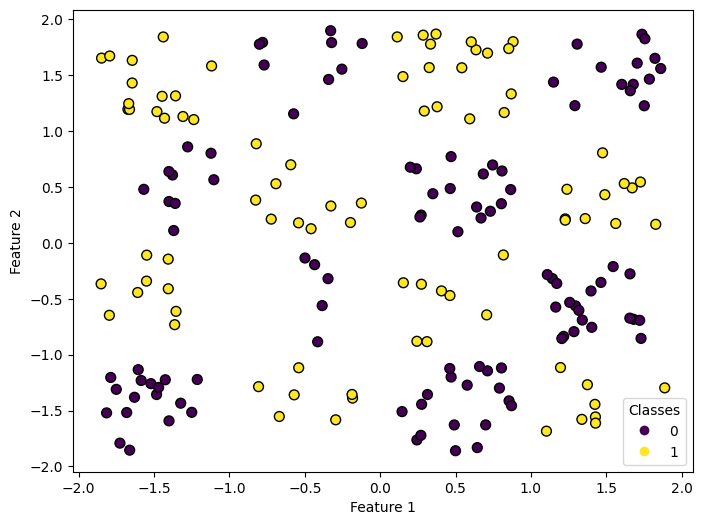

In [8]:
# Generate the data
X_train, y_train = generate_grid_data(random_state=0)
X_test, y_test = generate_grid_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)

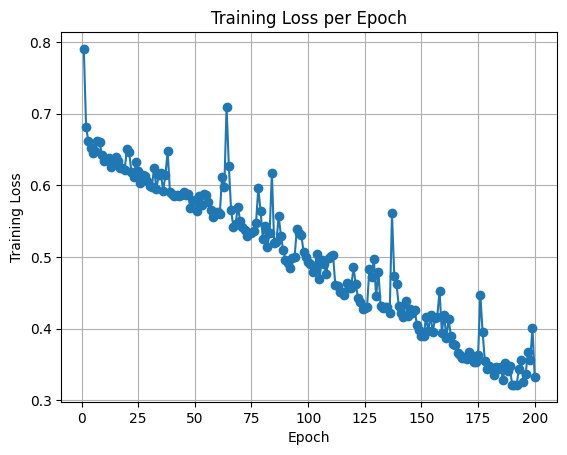

Evaluating EX2 Train Set:
Accuracy: 0.896


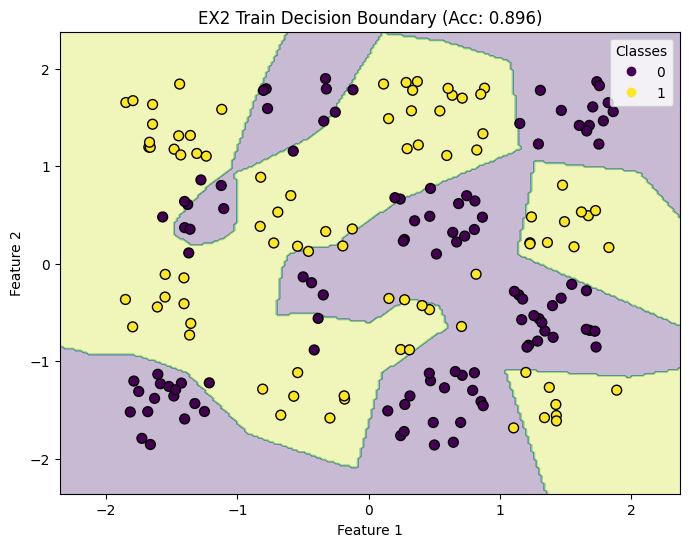


Evaluating EX2 Test Set:
Accuracy: 0.840


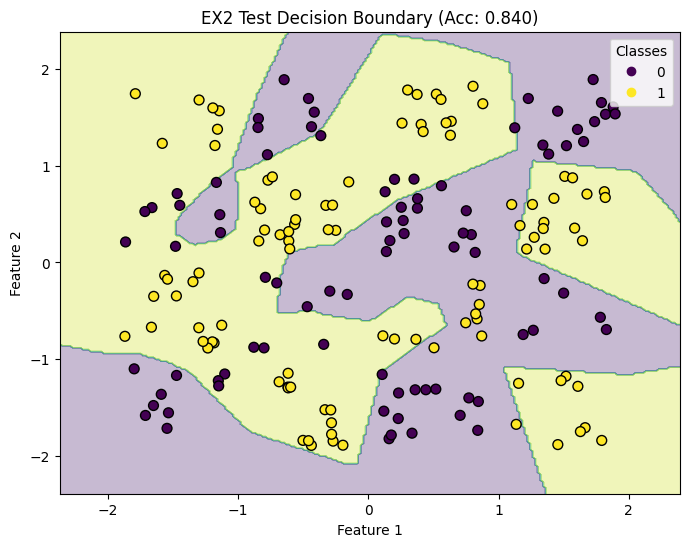

In [9]:
### Your code goes here ####
### EX2: Grid Data ###

# 2. Preprocess
train_loader, test_loader, input_dim, num_classes = preprocess(X_train, y_train, X_test, y_test)

# 3. Define the MLP Model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP, self).__init__()
        # Layer 1: Takes input (x, y) -> Transforms to 'hidden_dim' features
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Activation: ReLU (Rectified Linear Unit).
        # This introduces non-linearity. Without this, the network is just one big linear regression!
        self.relu = nn.ReLU()

        # Layer 2: Takes hidden features -> Transforms to output classes
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out) # Apply non-linearity
        out = self.fc2(out)
        return out

# Initialize the MLP
# hidden_dim=64 means we give the model 64 "neurons" in the middle layer to learn the grid patterns.
model_ex2 = MLP(input_dim=input_dim, hidden_dim=64, num_classes=num_classes)

# 4. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ex2.parameters(), lr=0.01) # Slightly smaller LR for stable training

# 5. Train
# We might need more epochs because this problem is harder than the triangles
model_ex2, losses = train_model(model_ex2, train_loader, criterion, optimizer, num_epochs=200)

# 6. Plot Loss
plot_training_loss(losses)

# 7. Evaluate
print("Evaluating EX2 Train Set:")
train_acc = evaluate_accuracy(model_ex2, train_loader)
plot_decision_boundary(model_ex2, X_train, y_train,
                       title=f"EX2 Train Decision Boundary (Acc: {train_acc:.3f})")

print("\nEvaluating EX2 Test Set:")
test_acc = evaluate_accuracy(model_ex2, test_loader)
plot_decision_boundary(model_ex2, X_test, y_test,
                       title=f"EX2 Test Decision Boundary (Acc: {test_acc:.3f})")

## EX3

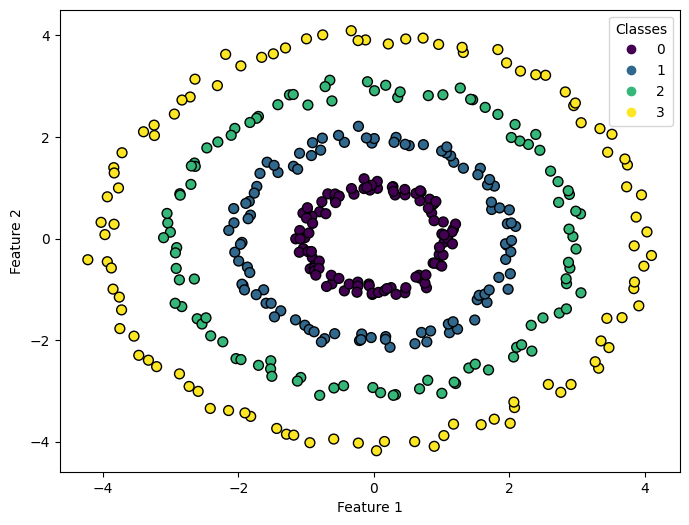

In [10]:
# Generate the data
X_train, y_train = generate_concentric_circles_data(random_state=0)
X_test, y_test = generate_concentric_circles_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)


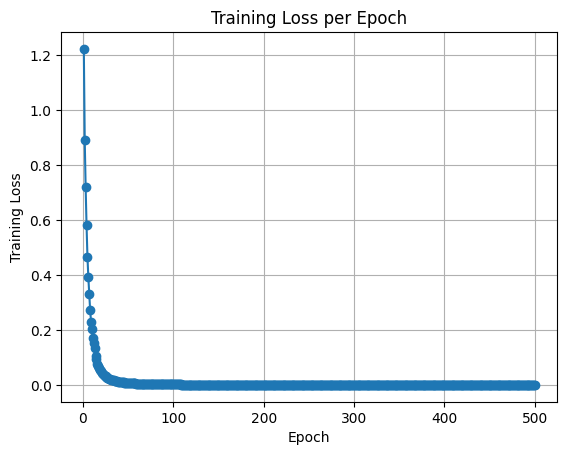

Evaluating EX3 Train Set:
Accuracy: 1.000


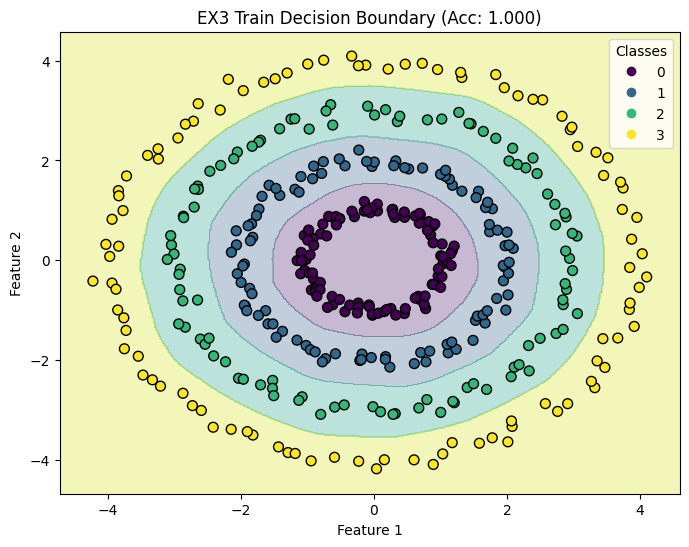


Evaluating EX3 Test Set:
Accuracy: 1.000


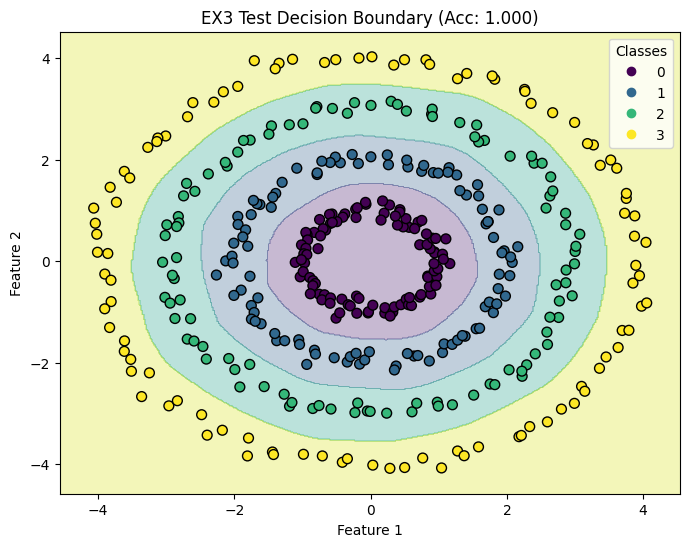

In [11]:
### Your code goes here ####

# 1. Preprocessing
train_loader, test_loader, input_dim, num_classes = preprocess(X_train, y_train, X_test, y_test)

# 2. Define the Model
class CircleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(CircleMLP, self).__init__()
        # Layer 1: Expansion
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Activation: The Hinge/Curve creator
        self.activation = nn.ReLU()
        # Layer 2: Compression/Classification
        self.layer2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Pass the bucket down the line
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out

# init MLP
model_ex3 = CircleMLP(input_dim,128,num_classes)

# Define the Loss Function (The Siren)
criterion = nn.CrossEntropyLoss()

# Define the Optimizer (The Tool)
# We pass the ACTUAL knobs (parameters), not just the size (hidden_dim)
optimizer = optim.Adam(model_ex3.parameters(), lr=0.01)

#3. Train the model
model_ex3, losses = train_model(model_ex3, train_loader, criterion, optimizer, num_epochs=500, device=None)

# 6. Plot Loss
plot_training_loss(losses)

# 7. Evaluate
print("Evaluating EX3 Train Set:")
train_acc = evaluate_accuracy(model_ex3, train_loader)
plot_decision_boundary(model_ex3, X_train, y_train,
                       title=f"EX3 Train Decision Boundary (Acc: {train_acc:.3f})")

print("\nEvaluating EX3 Test Set:")
test_acc = evaluate_accuracy(model_ex3, test_loader)
plot_decision_boundary(model_ex3, X_test, y_test,
                       title=f"EX3 Test Decision Boundary (Acc: {test_acc:.3f})")

## EX4

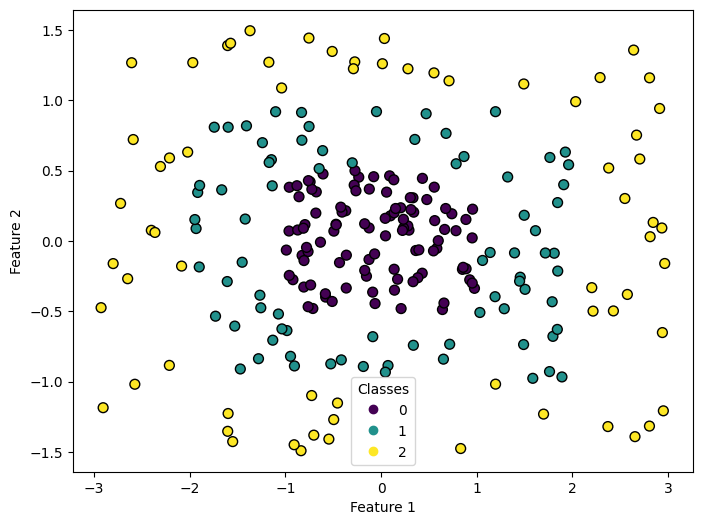

In [12]:


# Generate the data
X_train, y_train = generate_nested_rectangles_data(random_state=0)
X_test, y_test = generate_nested_rectangles_data(random_state=1)

# Plot the data
plot_data(X_train, y_train)

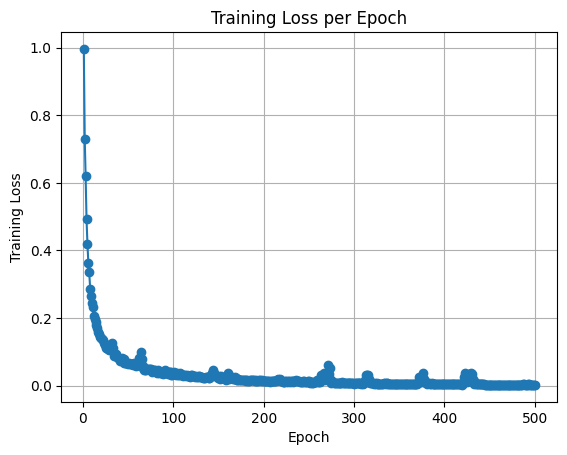

Evaluating EX4 Train Set:
Accuracy: 1.000


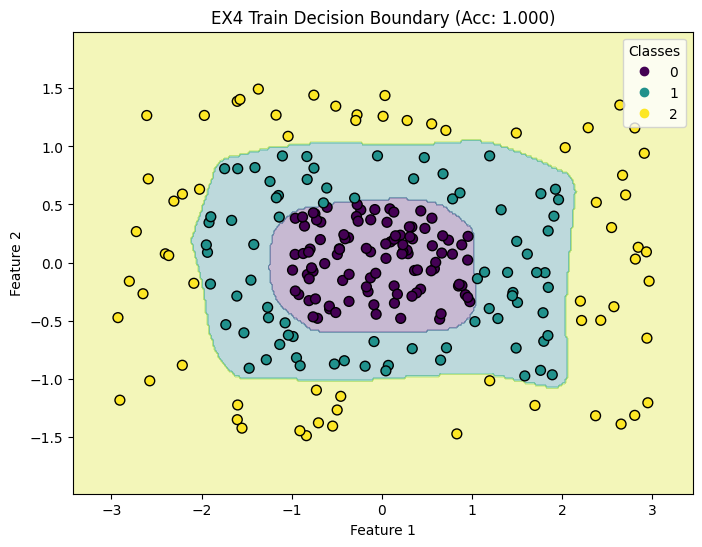


Evaluating EX4 Test Set:
Accuracy: 0.961


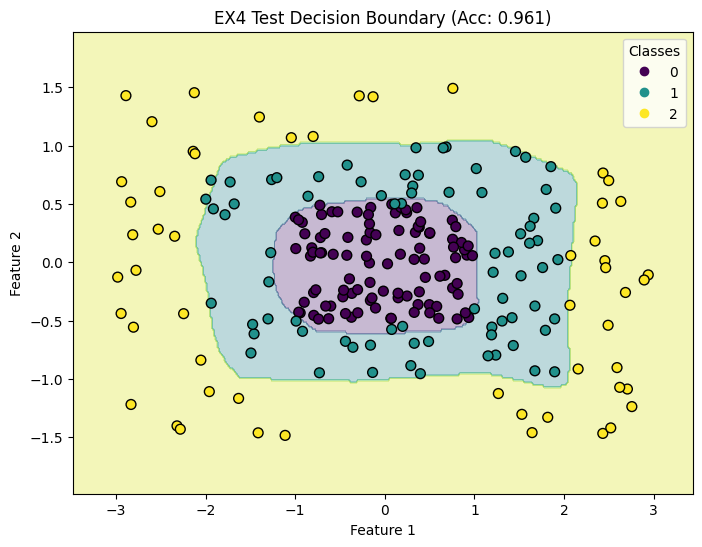

In [13]:
### Your code goes here ####

# 1. Preprocessing
train_loader, test_loader, input_dim, num_classes = preprocess(X_train, y_train, X_test, y_test)

# 2. Define the Model
class CircleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(CircleMLP, self).__init__()
        # Layer 1: Expansion
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Activation: The Hinge/Curve creator
        self.activation = nn.ReLU()
        # Layer 2: Compression/Classification
        self.layer2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Pass the bucket down the line
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out

# init MLP
model_ex4 = CircleMLP(input_dim,128,num_classes)

# Define the Loss Function (The Siren)
criterion = nn.CrossEntropyLoss()

# Define the Optimizer (The Tool)
# We pass the ACTUAL knobs (parameters), not just the size (hidden_dim)
optimizer = optim.Adam(model_ex4.parameters(), lr=0.01)

#3. Train the model
model_ex4, losses = train_model(model_ex4, train_loader, criterion, optimizer, num_epochs=500, device=None)

# 6. Plot Loss
plot_training_loss(losses)

# 7. Evaluate
print("Evaluating EX4 Train Set:")
train_acc = evaluate_accuracy(model_ex4, train_loader)
plot_decision_boundary(model_ex4, X_train, y_train,
                       title=f"EX4 Train Decision Boundary (Acc: {train_acc:.3f})")

print("\nEvaluating EX4 Test Set:")
test_acc = evaluate_accuracy(model_ex4, test_loader)
plot_decision_boundary(model_ex4, X_test, y_test,
                       title=f"EX4 Test Decision Boundary (Acc: {test_acc:.3f})")

## EX5 - Mystery Dataset
Load the data from the ex5.zip file:
X_train.npy
y_train.npy
X_test.npy
y_test.npy

Figure out the input and output dims and perform the classification task as in previous exercises.

You do not have to plot the data, but you may if you see fit.

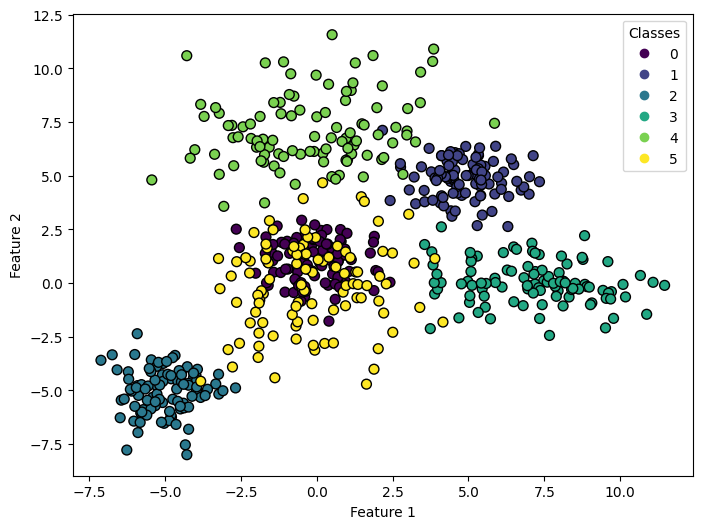

Data loaded successfully:
X_train shape: (600, 5)
y_train shape: (600,)
X_test shape: (600, 5)
y_test shape: (600,)
Input Dimension: 5, Number of Classes: 6


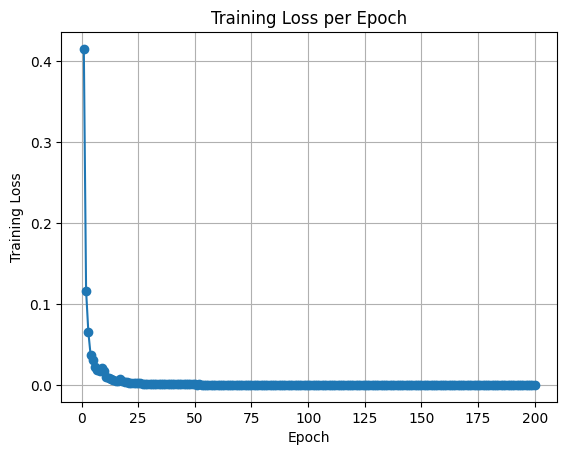

Evaluating Train Set:
Accuracy: 1.000

Evaluating Test Set:
Accuracy: 0.980


In [15]:
### Your code goes here ####

### load dumpy array using np.load()
## Load numpy arrays directly from the current directory.
# No need for zipfile if files are already extracted

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

plot_data(X_train, y_train)

print("Data loaded successfully:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")





### Figure out the data dimensions and Preprocessing
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))
print(f"Input Dimension: {input_dim}, Number of Classes: {num_classes}")

## Preprocessing (using your defined preprocess function)
train_loader, test_loader, input_dim, num_classes = preprocess(X_train, y_train, X_test, y_test)

### Init and train model. Report Accuracy
# 1. Model Definition
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out
model = MLP(input_dim=input_dim, hidden_dim=128, num_classes=num_classes)

# 2. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Train the Model
model, losses = train_model(model, train_loader, criterion, optimizer, num_epochs=200)

# 4. Plot Training Loss
plot_training_loss(losses)

# 5. Evaluation and Plotting
print("Evaluating Train Set:")
train_acc = evaluate_accuracy(model, train_loader)

print("\nEvaluating Test Set:")
test_acc = evaluate_accuracy(model, test_loader)

#Section 2: Regression Tasks
In this section your task is to predict the value of each point (indicated by the color in the scatter plots) using it's coordinates.
## TODO
For the entire section, do the following (i.e., only once):
1. Use the training function from previous section.
2. Use the plotting function from previous section to plot the loss.
3. Use the provided plotting function to plot the data with your predicted label values. For instance:


```
plot_s_curve(X_train, y_train_pred)
```


4. Write a preprocessing function for the inputs (convert to torch tensor, etc).
5. Write an evaluation function that prints the set Mean Square Error (train/test).

For each of the 3 exercises, do the following:
1. Create an MLP using PyTorch.
2. Train the model and plot the loss across epochs.
3. Plot the predicted values for the train set. Show the MSE in the title (up to 3 decimals points).
4. Plot the predicted values for the test set. Show the MSE in the title (up to 3 decimals points).
5. Create a Markdown cell and explain briefly (2-3 lines): why did the model perform well/poorly? What affected your design choices?

**Grading**: in this section you are only graded on the correctness of your code and discussion.

**Optional**: you may want to plot the residuals between your model prediction and the true labels. For instance, you may plot the data and use the differences between the true and predicted labels as their color.

## Setup

In [19]:
from sklearn.datasets import make_s_curve
### EX7
def generate_s_curve_data(n_samples=150, random_state=42):
    X, t = make_s_curve(n_samples, random_state=random_state)
    X = X[:, [0, 2]]  # Use only 2D input (X[:, 0] and X[:, 2])
    return X, t

def create_labels_s_curve(X, t):
    # Sort the indices based on the S-curve parameter t
    sorted_indices = np.argsort(t)
    labels = np.linspace(-1, 1, len(t))
    y = np.zeros_like(t)
    y[sorted_indices] = labels
    return y

def plot_s_curve(X, y, title='S-Curve'):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.colorbar(scatter, label='Label')
    plt.show()


### EX8
def generate_spiral_data(n_points=1000, n_turns=2.5, noise=0.05, random_state=42):
    np.random.seed(random_state)
    theta = np.linspace(0, n_turns * 2 * np.pi, n_points)
    r = np.linspace(0, 1, n_points)
    x = r * np.cos(theta) + noise * np.random.randn(n_points)
    y = r * np.sin(theta) + noise * np.random.randn(n_points)
    X = np.vstack((x, y)).T
    return X, theta

def create_labels_spiral(theta):
    labels = np.linspace(-1, 1, len(theta))
    return labels

def plot_spiral(X, y, title='Spiral'):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.colorbar(scatter, label='Label')
    plt.show()

### EX9
def generate_spiral_data_3d(n_points=1000, n_turns=2.5, noise=0.05, random_state=42):
    np.random.seed(random_state)
    theta = np.linspace(0, n_turns * 2 * np.pi, n_points)
    z = np.linspace(0, 1, n_points)
    r = z
    x = r * np.cos(theta) + noise * np.random.randn(n_points)
    y = r * np.sin(theta) + noise * np.random.randn(n_points)
    X = np.vstack((x, y, z)).T
    return X, theta

def create_labels_3d_spiral(theta):
    labels = np.linspace(-1, 1, len(theta))
    return labels

def plot_spiral_3d(X, y, title='3D Spiral'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', edgecolor='k')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label='Label')
    plt.show()

## TODO - You general functions for Section 2

In [18]:
### Your code goes here ###
### Imports
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import Axes3D for 3D plotting

### Preprocessing function ####
def preprocess(X_train, y_train, X_test=None, y_test=None, batch_size=32):
    # 1. Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Add unsqueeze(1) for regression target to be (N, 1)

    # 2. Train dataset + loader
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # 3. Optional test loader
    test_loader = None
    if X_test is not None and y_test is not None:
        x_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1) # Convert to float32 and unsqueeze(1)
        test_dataset = torch.utils.data.TensorDataset(x_test_tensor, y_test_tensor)
        test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 4. Useful info for building the model
    input_dim = X_train.shape[1] # Calculate input_dim

    return train_loader, test_loader, input_dim # Return input_dim




### Training function ###
def train_model(model, train_loader, criterion, optimizer, num_epochs=100, device=None):
    """
    Training loop for a PyTorch model.
    Returns:
        - trained model
        - list of training losses (one value per epoch)
    """

    # If no device is given, choose GPU if available, otherwise CPU
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the model to the selected device (CPU or GPU)
    model.to(device)

    # List for saving the loss of each epoch
    train_losses = []

    # Loop over all epochs (full passes over the dataset)
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode (important for layers like Dropout)

        running_loss = 0.0   # Total loss for this epoch
        num_samples = 0      # How many samples we processed

        # Loop over all batches in the training dataset
        for X_batch, y_batch in train_loader:

            # Move the batch data to the device (CPU/GPU)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Clear old gradients from previous step
            optimizer.zero_grad()

            # Forward pass: compute model predictions
            outputs = model(X_batch)

            # Compute how wrong the predictions are
            loss = criterion(outputs, y_batch)

            # Backward pass: compute gradients of loss w.r.t parameters
            loss.backward()

            # Update the model parameters using the optimizer
            optimizer.step()

            # Get batch size (how many samples are inside this batch)
            batch_size = X_batch.size(0)

            # Add the batch loss to the running total (multiply by batch size)
            running_loss += loss.item() * batch_size

            # Count how many samples we processed so far
            num_samples += batch_size

        # Compute average loss over all samples in this epoch
        epoch_loss = running_loss / num_samples

        # Save this epoch's loss
        train_losses.append(epoch_loss)

        # Optional: print progress
        # print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

    # Return trained model and list of epoch losses
    return model, train_losses


### Plot training loss function ###


def plot_training_loss(train_losses):
    """
    Plot the training loss per epoch.

    Args:
        train_losses: list of floats.
                      train_losses[i] is the loss at epoch (i+1).
    """
    # Create a list of epoch numbers: [1, 2, 3, ..., num_epochs]
    epochs = range(1, len(train_losses) + 1)
    # Start a new figure (a new empty plot)
    plt.figure()
    # Draw the loss curve: x = epochs, y = loss values
    plt.plot(epochs, train_losses, marker="o")
    # Add a label for the x-axis
    plt.xlabel("Epoch")
    # Add a label for the y-axis
    plt.ylabel("Training Loss")
    # Add a title at the top of the plot
    plt.title("Training Loss per Epoch")
    # (Optional) Add a grid to make it easier to read values
    plt.grid(True)
    # Show the plot on the screen
    plt.show()


### Evaluation function for Regression (Mean Squared Error) ###
def evaluate_accuracy(model, data_loader, device=None):
    """
    Calculates Mean Squared Error (MSE) on a given dataset.
    Note: This function is named evaluate_accuracy but calculates MSE for regression.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval() # Set model to evaluation mode

    mse_sum = 0.0
    total_samples = 0

    with torch.no_grad(): # Turn off gradient calculation
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            mse_sum += torch.sum((outputs - y_batch)**2).item() # Sum of squared differences
            total_samples += y_batch.size(0)

    mse = mse_sum / total_samples
    print(f"MSE: {mse:.3f}")
    return mse


### Plot predicted labels and regression surface (2D) ###
def plot_decision_boundary(model, X, y, device=None, title="Regression Surface"):
    """
    Plots the data points (X, y) and the predicted regression surface of the model.
    X, y: Original numpy arrays (not tensors/loaders) for easy plotting.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval() # Set model to evaluation mode

    # 1. Create a meshgrid (the background grid)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 2. Flatten and convert to tensor for the model
    # ravel() flattens the array. np.c_ stacks them side-by-side to make (N, 2) coordinates
    mesh_input = np.c_[xx.ravel(), yy.ravel()]
    mesh_tensor = torch.tensor(mesh_input, dtype=torch.float32).to(device)

    # 3. Get predictions for the whole grid
    with torch.no_grad():
        outputs = model(mesh_tensor)
        # For regression, outputs are direct continuous values. Squeeze to remove extra dimension.
        Z_pred = outputs.cpu().numpy().squeeze()

    # 4. Reshape predictions to match the grid shape
    Z = Z_pred.reshape(xx.shape)

    # 5. Plotting
    plt.figure(figsize=(8, 6))

    # Draw the filled contour (the predicted regression surface)
    contour = plt.contourf(xx, yy, Z, alpha=0.6, cmap='viridis', levels=50)
    plt.colorbar(contour, label='Predicted Value') # Add colorbar for predicted values

    # scatter plot of the actual data points (colored by their true 'y' values)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50, alpha=0.8)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    # Remove the legend for classes, as it's not applicable for continuous output in this context.
    # plt.legend(handles=scatter.legend_elements()[0], labels=set(y), title="Classes")
    plt.show()

### Plotting function for 3D Spiral Regression ###
def plot_spiral_3d(X, y, title='3D Spiral'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', edgecolor='k')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label='Label')
    plt.show()

## EX6

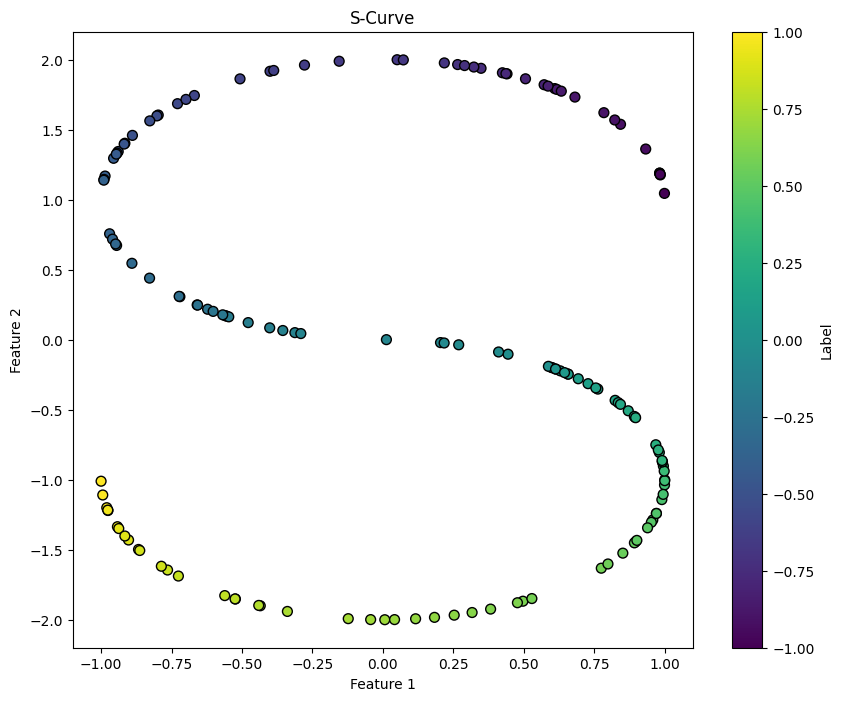

In [21]:
# Generate the data
X_train, theta_train = generate_s_curve_data(random_state=0)
X_test, theta_test = generate_s_curve_data(random_state=1)

# Create the labels
y_train = create_labels_s_curve(X_train, theta_train)
y_test = create_labels_s_curve(X_test, theta_test)

# Plot the data
plot_s_curve(X_train, y_train)

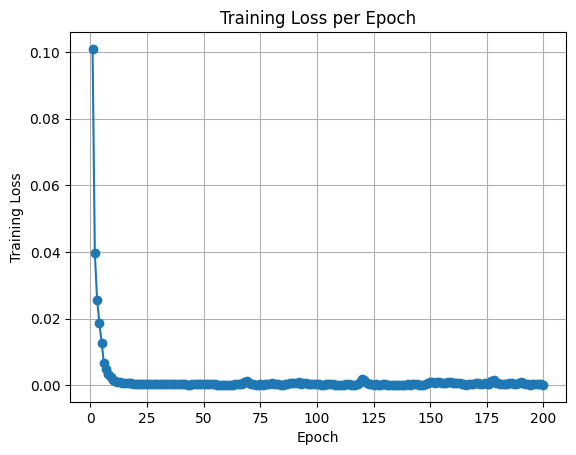

Evaluating Train Set:
MSE: 0.000


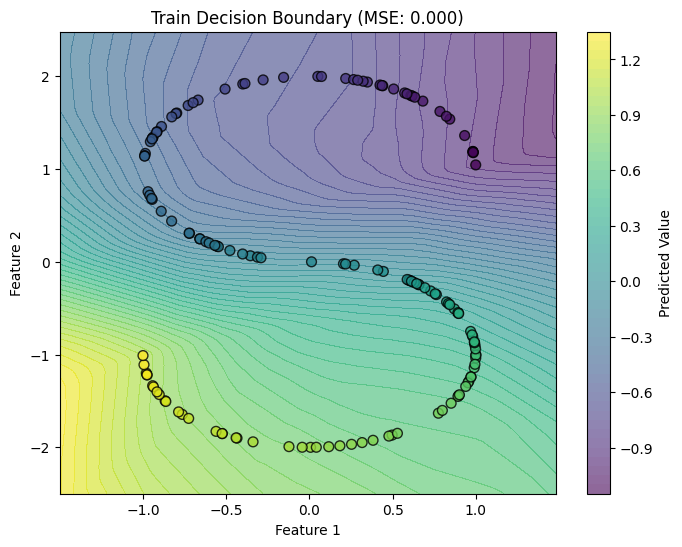


Evaluating Test Set:
MSE: 0.009


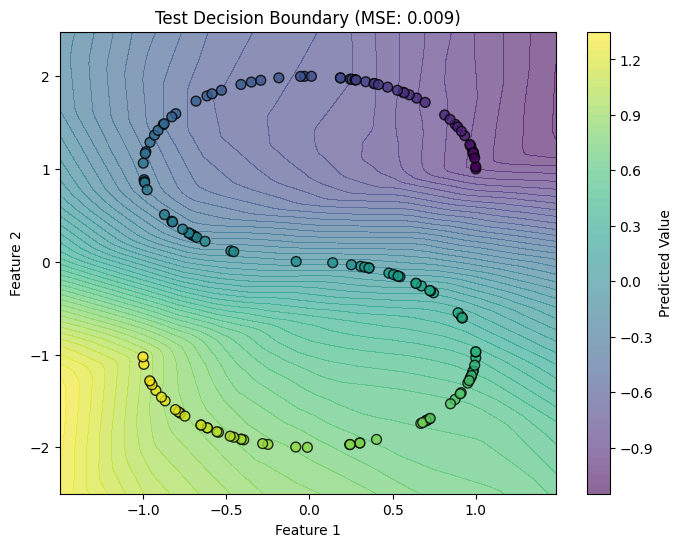

In [22]:
### Your code goes here ####

# What did I do? or should do to switch to regression instead of classification?
## change the preprocess tensor Y to a float
## Change the loss function to MSE (that works with regression problems)
## Change the output of the NN to 1 diamention
## Plot base on those changes

### Your code goes here ####

# 1. Preprocessing
train_loader, test_loader, input_dim = preprocess(X_train, y_train, X_test, y_test)

# 2. Define the Model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLP, self).__init__()
        # Layer 1: Expansion
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Activation: The Hinge/Curve creator
        self.activation = nn.ReLU()
        # Layer 2: Compression/Classification
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Pass the bucket down the line
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out

# init MLP
model = MLP(input_dim,128)

# Define the Loss Function (The Siren)
criterion = nn.MSELoss()

# Define the Optimizer (The Tool)
# We pass the ACTUAL knobs (parameters), not just the size (hidden_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)

#3. Train the model
model, losses = train_model(model, train_loader, criterion, optimizer, num_epochs=200, device=None)

# 6. Plot Loss
plot_training_loss(losses)

# 7. Evaluate
print("Evaluating Train Set:")
train_acc = evaluate_accuracy(model, train_loader)
plot_decision_boundary(model, X_train, y_train,
                       title=f"Train Decision Boundary (MSE: {train_acc:.3f})")

print("\nEvaluating Test Set:")
test_acc = evaluate_accuracy(model, test_loader)
plot_decision_boundary(model, X_test, y_test,
                       title=f"Test Decision Boundary (MSE: {test_acc:.3f})")

## EX7

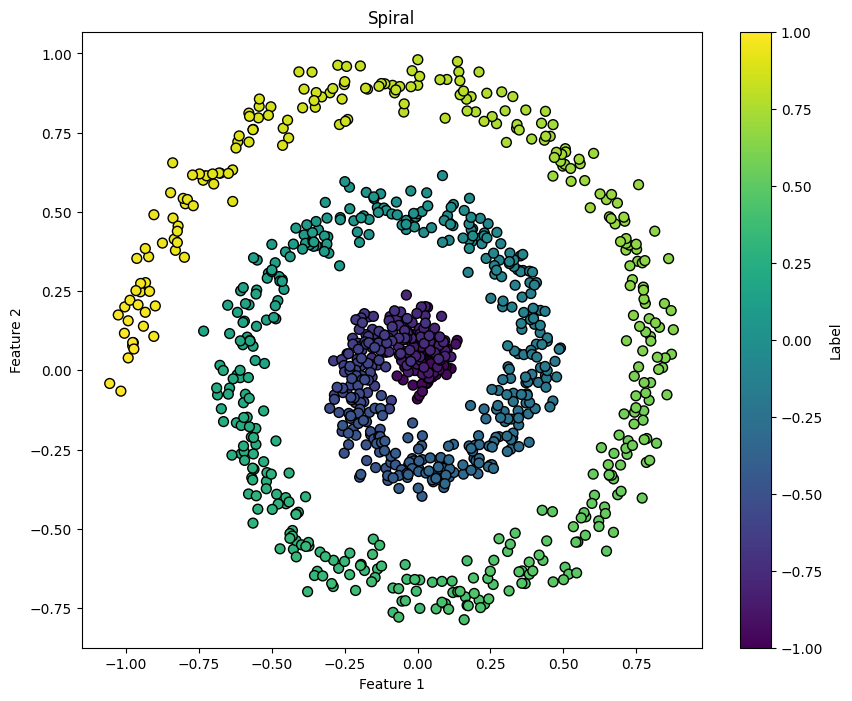

In [23]:
# Generate the data
X_train, theta_train = generate_spiral_data(random_state=0)
X_test, theta_test = generate_spiral_data(random_state=1)
# Create the labels
y_train = create_labels_spiral(theta_train)
y_test = create_labels_spiral(theta_test)
# Plot the data
plot_spiral(X_train, y_train)


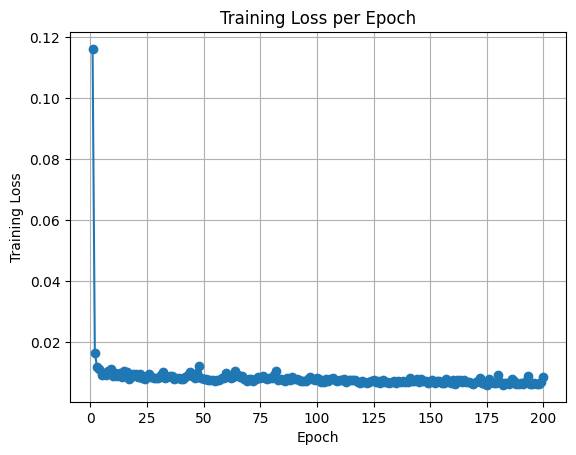

Evaluating Train Set:
MSE: 0.009


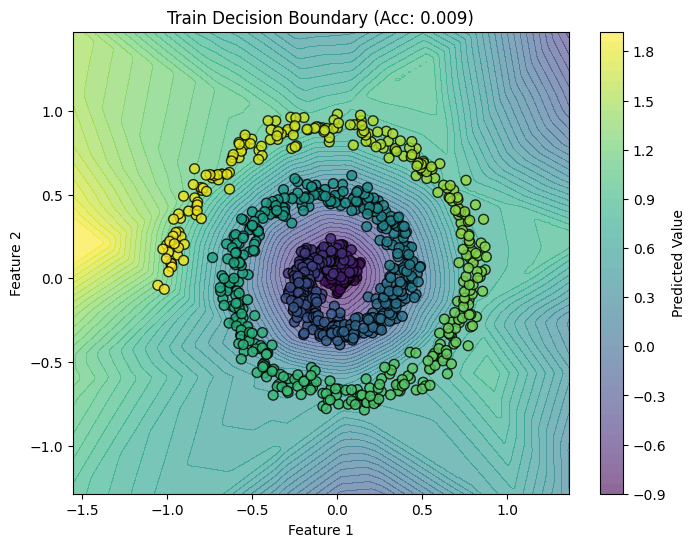


Evaluating Test Set:
MSE: 0.011


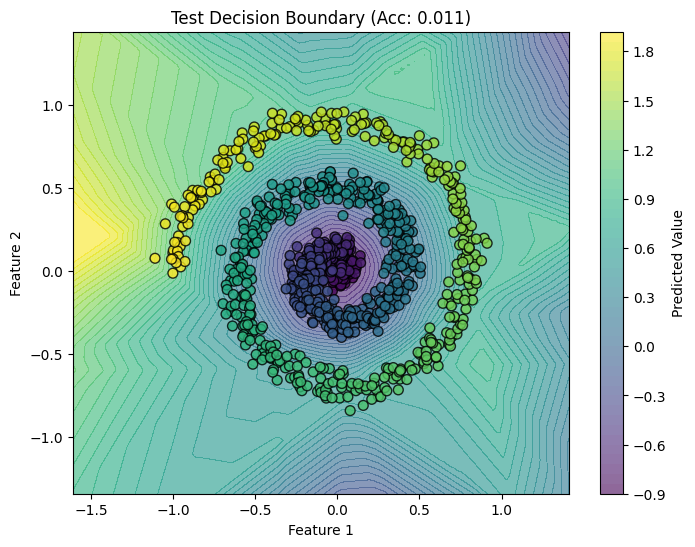

In [24]:
### Your code goes here ####
### Your code goes here ####

# What did I do? or should do to switch to regression instead of classification?
## change the preprocess tensor Y to a float
## Change the loss function to MSE (that works with regression problems)
## Change the output of the NN to 1 diamention
## Plot base on those changes

### Your code goes here ####

# 1. Preprocessing
train_loader, test_loader, input_dim = preprocess(X_train, y_train, X_test, y_test)

# 2. Define the Model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLP, self).__init__()
        # Layer 1: Expansion
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Activation: The Hinge/Curve creator
        self.activation = nn.ReLU()
        # Layer 2: Compression/Classification
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Pass the bucket down the line
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out

# init MLP
model = MLP(input_dim,128)

# Define the Loss Function (The Siren)
criterion = nn.MSELoss()

# Define the Optimizer (The Tool)
# We pass the ACTUAL knobs (parameters), not just the size (hidden_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)

#3. Train the model
model, losses = train_model(model, train_loader, criterion, optimizer, num_epochs=200, device=None)

# 6. Plot Loss
plot_training_loss(losses)

# 7. Evaluate
print("Evaluating Train Set:")
train_acc = evaluate_accuracy(model, train_loader)
plot_decision_boundary(model, X_train, y_train,
                       title=f"Train Decision Boundary (Acc: {train_acc:.3f})")

print("\nEvaluating Test Set:")
test_acc = evaluate_accuracy(model, test_loader)
plot_decision_boundary(model, X_test, y_test,
                       title=f"Test Decision Boundary (Acc: {test_acc:.3f})")

## EX8

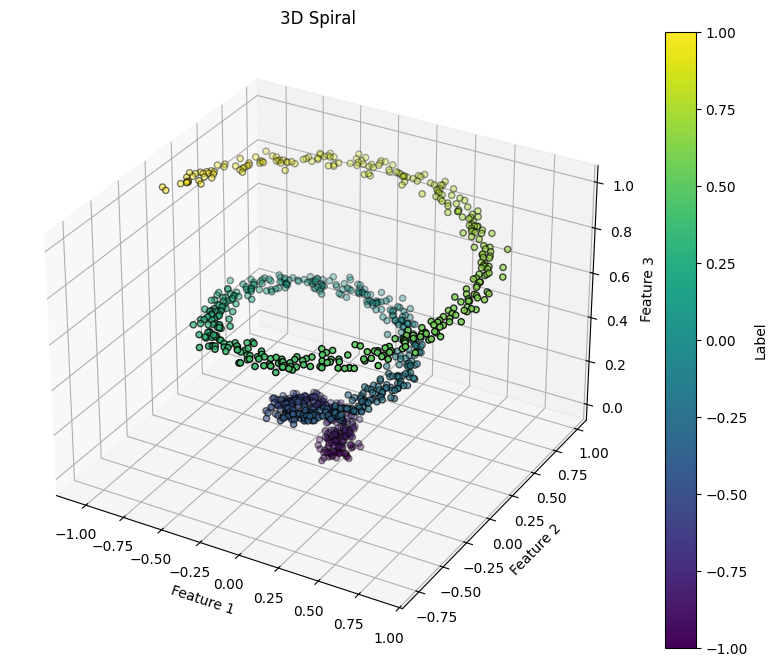

In [25]:
# Generate the data
X_train, theta_train = generate_spiral_data_3d(random_state=0)
X_test, theta_test = generate_spiral_data_3d(random_state=1)

# Create the labels
y_train = create_labels_3d_spiral(theta_train)
y_test = create_labels_3d_spiral(theta_test)

# Plot the data
plot_spiral_3d(X_train, y_train)

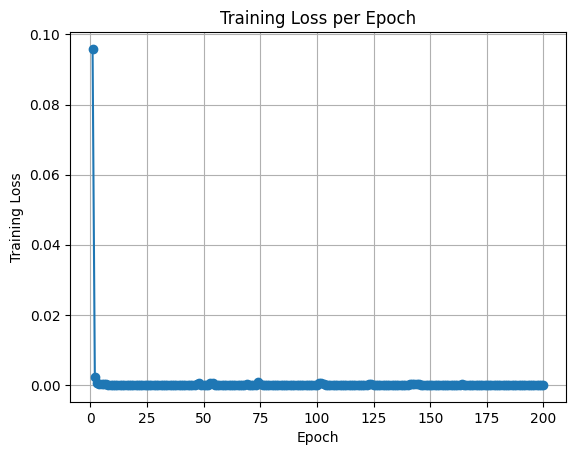

Evaluating Train Set:
MSE: 0.000


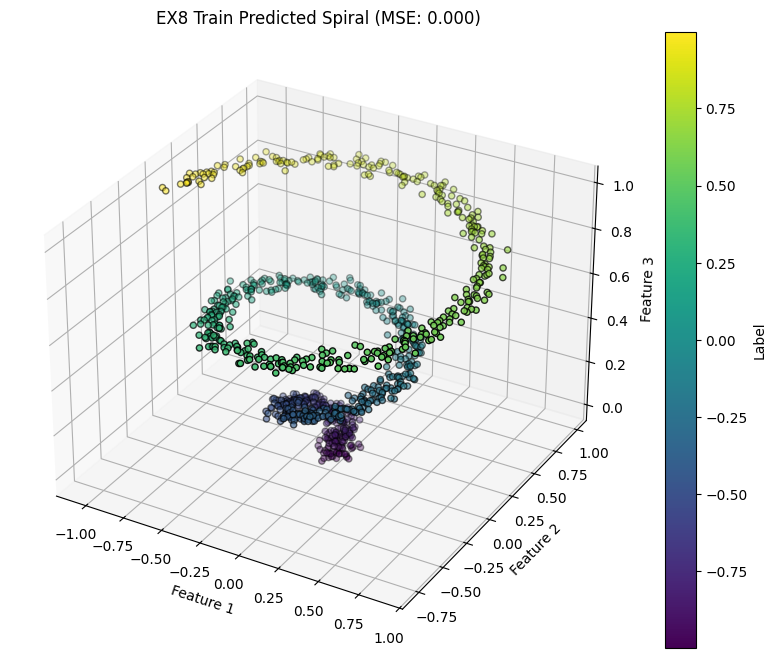


Evaluating Test Set:
MSE: 0.000


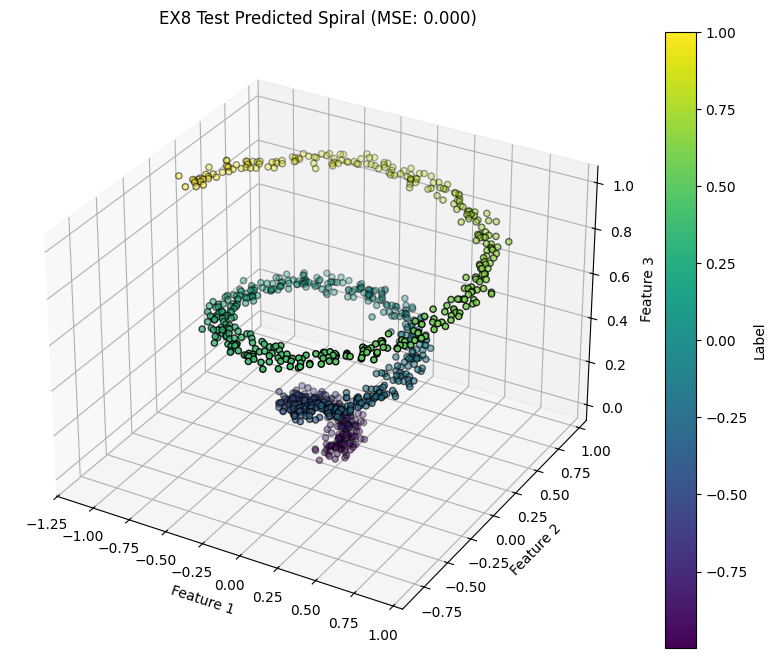

In [26]:
### Your code goes here ####

# What did I do? or should do to switch to regression instead of classification?
## change the preprocess tensor Y to a float
## Change the loss function to MSE (that works with regression problems)
## Change the output of the NN to 1 diamention
## Plot base on those changes

### Your code goes here ####

# 1. Preprocessing
train_loader, test_loader, input_dim = preprocess(X_train, y_train, X_test, y_test)

# 2. Define the Model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLP, self).__init__()
        # Layer 1: Expansion
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Activation: The Hinge/Curve creator
        self.activation = nn.ReLU()
        # Layer 2: Compression/Classification
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Pass the bucket down the line
        out = self.layer1(x)
        out = self.activation(out)
        out = self.layer2(out)
        return out

# init MLP
model = MLP(input_dim,128)

# Define the Loss Function (The Siren)
criterion = nn.MSELoss()

# Define the Optimizer (The Tool)
# We pass the ACTUAL knobs (parameters), not just the size (hidden_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)

#3. Train the model
model, losses = train_model(model, train_loader, criterion, optimizer, num_epochs=200, device=None)

# 6. Plot Loss
plot_training_loss(losses)

# 7. Evaluate and Plot for EX8 (3D Spiral)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode

# --- Train Set ---
print("Evaluating Train Set:")
train_mse = evaluate_accuracy(model, train_loader) # evaluate_accuracy now calculates MSE

# Get predictions for plotting
with torch.no_grad():
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_pred = model(X_train_tensor).cpu().numpy().squeeze()

plot_spiral_3d(X_train, y_train_pred, title=f"EX8 Train Predicted Spiral (MSE: {train_mse:.3f})")

# --- Test Set ---
print("\nEvaluating Test Set:")
test_mse = evaluate_accuracy(model, test_loader) # evaluate_accuracy now calculates MSE

# Get predictions for plotting
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_pred = model(X_test_tensor).cpu().numpy().squeeze()

plot_spiral_3d(X_test, y_test_pred, title=f"EX8 Test Predicted Spiral (MSE: {test_mse:.3f})")

In [ ]:
import zipfile
import numpy as np

# Assuming ex5.zip is in the current directory or specified path
zip_file_path = 'ex5.zip'
extraction_path = './ex5_data'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")

# Load the data
X_train = np.load(f'{extraction_path}/X_train.npy')
y_train = np.load(f'{extraction_path}/y_train.npy')
X_test = np.load(f'{extraction_path}/X_test.npy')
y_test = np.load(f'{extraction_path}/y_test.npy')

print("Data loaded successfully:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Now that the data is loaded, I will continue with the rest of EX5, which involves determining input/output dimensions, initializing a model, training it, and reporting the accuracy.

In [ ]:
### Your code goes here ####

## Figure out the data dimensions
input_dim_ex5 = X_train.shape[1]
num_classes_ex5 = len(np.unique(y_train))

print(f"Input Dimension for EX5: {input_dim_ex5}")
print(f"Number of Classes for EX5: {num_classes_ex5}")

### Preprocessing
train_loader_ex5, test_loader_ex5, _, _ = preprocess(X_train, y_train, X_test, y_test)

### Model Definition (MLP)
class MLP_Ex5(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLP_Ex5, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initialize the MLP for EX5
model_ex5 = MLP_Ex5(input_dim=input_dim_ex5, hidden_dim=128, num_classes=num_classes_ex5)

### Training Setup
criterion_ex5 = nn.CrossEntropyLoss()
optimizer_ex5 = optim.Adam(model_ex5.parameters(), lr=0.01)

### Train the Model
model_ex5, losses_ex5 = train_model(model_ex5, train_loader_ex5, criterion_ex5, optimizer_ex5, num_epochs=200)

### Plot Training Loss
plot_training_loss(losses_ex5)

### Evaluation
print("Evaluating EX5 Train Set:")
train_acc_ex5 = evaluate_accuracy(model_ex5, train_loader_ex5)
plot_decision_boundary(model_ex5, X_train, y_train,
                       title=f"EX5 Train Decision Boundary (Acc: {train_acc_ex5:.3f})")

print("\nEvaluating EX5 Test Set:")
test_acc_ex5 = evaluate_accuracy(model_ex5, test_loader_ex5)
plot_decision_boundary(model_ex5, X_test, y_test,
                       title=f"EX5 Test Decision Boundary (Acc: {test_acc_ex5:.3f})")

# MNIST Binary Classification Task (20 pts.)
## EX9
Perform a binray classification task on the MNIST dataset between two digits (you may choose any two digits).
### You are required to do the following:
1. Create a subset of the train/test sets for the two digits you have chosen
2. Create a validation set out of the train set (80%-20% split)
3. Normalize the data
4. Write a training function
5. Write an evaluation function that returns the accuracy
6. Plot the training and validation accuracy for each epoch
7. Plot 10 test images of each class with their predicited labels
8. Print the test set accuracy

### Hyperparameters:
Briefly explain why you have chosen each parameter:
1. Model: MLP, CNN (both are valid options)
2. Number of layers, number of neurons/kernels, kernel size
3. Number of epochs (between 10-100)
4. Learning rate
5. Loss function
6. Activation function

**Grading**: Correctness and discussion. You are not grade on accuracy in this section.

### Discuss the results (3-5 lines)
Did the model converge? did it overfit? How is classifying images different from the toy examples we saw? Write you overall first impressions after solving this HW.

Running on: cuda
Starting training...
Epoch 5/20 | Loss: 0.0113 | Val Acc: 0.9944
Epoch 10/20 | Loss: 0.0016 | Val Acc: 0.9976
Epoch 15/20 | Loss: 0.0004 | Val Acc: 0.9972
Epoch 20/20 | Loss: 0.0002 | Val Acc: 0.9964


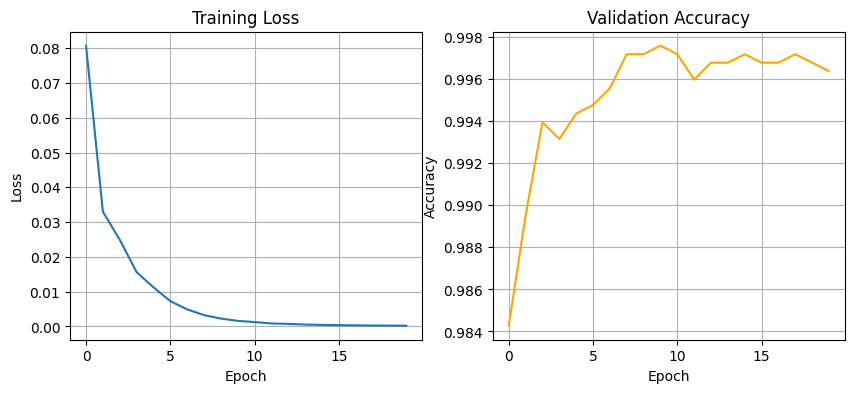

Final Test Accuracy: 99.26%


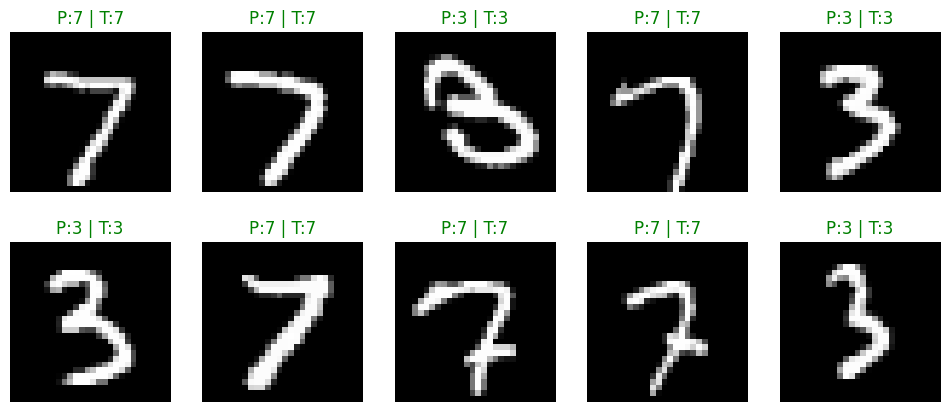

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import DataLoader, random_split, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Data Preparation
# ==========================================
def get_data_loaders(d1, d2, batch_size=64):
    train_full = datasets.MNIST(root='./data', train=True, download=True)
    test_full = datasets.MNIST(root='./data', train=False, download=True)

    def prepare_data(dataset):
        idx = (dataset.targets == d1) | (dataset.targets == d2)
        data = dataset.data[idx].flatten(1).float() / 255.0
        targets = dataset.targets[idx]

        # Map targets: d1 -> 0, d2 -> 1
        new_targets = torch.zeros_like(targets)
        new_targets[targets == d2] = 1

        return TensorDataset(data, new_targets)

    train_filtered = prepare_data(train_full)
    test_filtered = prepare_data(test_full)

    train_size = int(0.8 * len(train_filtered))
    val_size = len(train_filtered) - train_size
    train_subset, val_subset = random_split(train_filtered, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_filtered, batch_size=batch_size, shuffle=False)

    input_dim = train_filtered.tensors[0].shape[1]

    return train_loader, val_loader, test_loader, input_dim

# ==========================================
# 2. Model Definition (MLP)
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        # Output: 2 neurons (one for each class)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc3(out)
        return out

# ==========================================
# 3. Training & Evaluation Functions
# ==========================================
def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)

            # Get predictions using argmax
            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    model.to(device)
    train_losses = []
    val_accuracies = []

    print("Starting training...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validate
        val_acc = evaluate_accuracy(model, val_loader, device)
        val_accuracies.append(val_acc)

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model, train_losses, val_accuracies

def plot_results(train_losses, val_accuracies):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy', color='orange')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True)
    plt.show()

def plot_image_predictions(model, test_loader, digit1, digit2, device):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    class_map = {0: str(digit1), 1: str(digit2)}

    plt.figure(figsize=(12, 5))
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)

        # Reshape back to 28x28 for display
        img_to_show = images[i].cpu().view(28, 28)
        plt.imshow(img_to_show, cmap='gray')

        p = class_map[int(preds[i].item())]
        t = class_map[int(labels[i].item())]

        color = 'green' if p == t else 'red'
        plt.title(f"P:{p} | T:{t}", color=color)
        plt.axis('off')
    plt.show()

# ==========================================
# 4. Main Execution
# ==========================================
# Hyperparameters
DIGIT_1, DIGIT_2 = 3, 7
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on: {DEVICE}")

# Run Pipeline
train_loader, val_loader, test_loader, input_dim = get_data_loaders(DIGIT_1, DIGIT_2, BATCH_SIZE)

model = MLP(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

trained_model, train_losses, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, EPOCHS, DEVICE
)

plot_results(train_losses, val_accuracies)

final_acc = evaluate_accuracy(trained_model, test_loader, DEVICE)
print(f"Final Test Accuracy: {final_acc*100:.2f}%")

plot_image_predictions(trained_model, test_loader, DIGIT_1, DIGIT_2, DEVICE)